# Analisis Sentimen Ulasan Aplikasi **MyTelkomsel**

**Proyek Analisis Sentimen — Belajar Fundamental Deep Learning (Dicoding)**

Notebook ini membangun model **klasifikasi sentimen 3 kelas** (negatif / netral / positif)
dari **ulasan Bahasa Indonesia aplikasi MyTelkomsel** (`com.telkomsel.telkomselcm`) di
Google Play Store, yang di-**scraping mandiri** (lihat `scraping_mytelkomsel.py`).

**Alur pengerjaan (8 tahap):**
`scraping → EDA → preprocessing teks → pelabelan hybrid → 4 skema pelatihan → evaluasi → inference → kesimpulan`

**Ringkasan pemenuhan kriteria & saran:**

| Aspek | Status |
|---|---|
| Data hasil scraping mandiri (min 3.000) | ✅ 58.000 ulasan (stratified per bintang) |
| Ekstraksi fitur + pelabelan | ✅ TF-IDF / Embedding + hybrid rating+lexicon |
| Algoritma machine learning | ✅ SVM, BiLSTM, CNN, IndoBERT |
| Akurasi testing ≥ 85% | ✅ semua skema |
| (Saran 1) Deep learning | ✅ BiLSTM, CNN, IndoBERT |
| (Saran 2) Train & test > 92% | ✅ IndoBERT |
| (Saran 3) ≥ 3 kelas | ✅ negatif / netral / positif |
| (Saran 4) ≥ 10.000 sampel | ✅ 14.671 sampel berlabel |
| (Saran 5) ≥ 3 skema pelatihan | ✅ 4 skema (variasi algoritma + fitur + split) |
| (Saran 6) Inference output kategorikal | ✅ di Tahap 7 |

**Peningkatan mengikuti saran reviewer (belajar hal baru):** MPStemmer (stemming cepat),
`sklearn.Pipeline`, Cross-Validation, metrik lengkap + confusion matrix, **Error Analysis**,
**XAI** (LIME + bobot kata) + **PCA/t-SNE**, analisis emosi **NRCLex**, serta
**fit ekstraksi fitur hanya di data latih** (mencegah *data leak*).

## 0. Import Library & Konfigurasi

In [1]:
import os
import re
import json
import time
import random
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud

# Preprocessing Bahasa Indonesia
from Sastrawi.StopWordRemover.StopWordRemoverFactory import StopWordRemoverFactory
from mpstemmer import MPStemmer  # saran reviewer: stemming jauh lebih cepat dari Sastrawi

# Ekstraksi fitur + machine learning klasik
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import LinearSVC
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import LabelEncoder
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import (accuracy_score, f1_score, classification_report,
                             confusion_matrix)
from sklearn.decomposition import TruncatedSVD
from sklearn.manifold import TSNE

# Deep learning
import tensorflow as tf
from tensorflow.keras import layers, Model, Sequential
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

# XAI (interpretabilitas model)
from lime.lime_text import LimeTextExplainer

warnings.filterwarnings("ignore")
sns.set_style("whitegrid")

# Reproducibility — kunci seed di semua sumber keacakan (saran: hasil dapat diulang)
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

# Palet warna konsisten untuk 3 kelas
ORDER = ["negatif", "netral", "positif"]
PAL = ["#ef4444", "#f59e0b", "#22c55e"]  # merah, oranye, hijau

print("TensorFlow :", tf.__version__)
print("Seed       :", SEED)

TensorFlow : 2.21.0
Seed       : 42


## Tahap 1 — Scraping Data (Google Play Store)

Data diambil sendiri dengan `google-play-scraper` (lihat berkas **`scraping_mytelkomsel.py`**).

**Strategi: stratified per rating bintang 1–5.** Rata-rata rating MyTelkomsel ~4,38 sehingga
ulasan bintang 5 mendominasi (~77%). Bila diambil acak, kelas **negatif** (bintang 1) dan
**netral** (bintang 3) akan tenggelam. Karena itu kami mengambil per bintang secara terpisah,
dengan **bintang 3 di-boost** (target 18.000) karena setelah pelabelan hanya sebagian kecil
bintang-3 yang menjadi netral murni. Kolom identitas pengguna (`userName`, `userImage`)
dibuang demi **privasi**.

Hasil: **58.000 ulasan unik**, rentang Okt 2024 – Jul 2026.

In [2]:
df_raw = pd.read_csv("dataset_mytelkomsel_reviews.csv")
print("Jumlah ulasan :", len(df_raw))
print("Kolom         :", list(df_raw.columns))
df_raw[["content", "score", "at", "thumbsUpCount"]].head()

Jumlah ulasan : 58000
Kolom         : ['reviewId', 'content', 'score', 'thumbsUpCount', 'reviewCreatedVersion', 'at', 'replyContent', 'repliedAt', 'appVersion']


,content,score,at,thumbsUpCount
0,"Jelek banget gila aplikasinya mental terus, cu...",1,2026-07-06 20:19:44,0
1,makin lama makin mahal udah sering gaada jarin...,1,2026-07-06 20:16:02,0
2,"Kenapa sinyal makin parah,kita main game onlin...",1,2026-07-06 20:15:49,0
3,KALO BISA KASIH BINTANG 0 SAYA KASIH BINTANG 0...,1,2026-07-06 20:09:27,0
4,makin ksini kualitas jaringan makin jelek buat...,1,2026-07-06 20:08:51,0


In [3]:
# Distribusi rating bintang (bukti stratifikasi) + cek data kosong
print("Distribusi rating bintang:")
print(df_raw["score"].value_counts().sort_index())
print("\nJumlah content kosong :", df_raw["content"].isna().sum())
print("Jumlah duplikat content:", df_raw["content"].duplicated().sum())

Distribusi rating bintang:
score
1    12000
2     8000
3    18000
4     8000
5    12000
Name: count, dtype: int64

Jumlah content kosong : 0
Jumlah duplikat content: 11703


## Tahap 2 — Exploratory Data Analysis (EDA)

Kita amati: (1) distribusi rating & proyeksi kelas, (2) panjang ulasan per kelas,
(3) tren volume ulasan dari waktu ke waktu, (4) kata paling sering (wordcloud) per kelas.

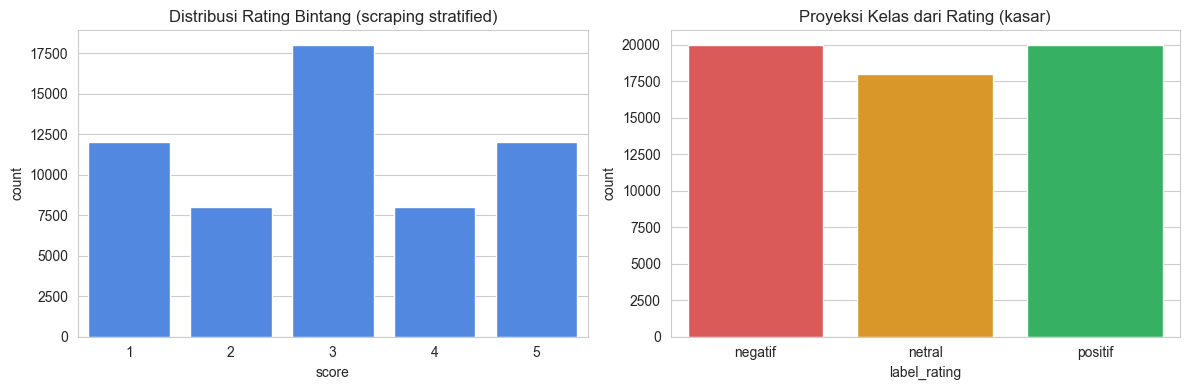

In [4]:
# Proyeksi kelas kasar dari rating (hanya untuk EDA awal, bukan label final)
df_raw["label_rating"] = np.where(df_raw.score <= 2, "negatif",
                                  np.where(df_raw.score == 3, "netral", "positif"))
df_raw["jml_kata"] = df_raw["content"].astype(str).str.split().apply(len)

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
sns.countplot(data=df_raw, x="score", ax=ax[0], color="#3b82f6")
ax[0].set_title("Distribusi Rating Bintang (scraping stratified)")
sns.countplot(data=df_raw, x="label_rating", order=ORDER, hue="label_rating",
              hue_order=ORDER, palette=PAL, legend=False, ax=ax[1])
ax[1].set_title("Proyeksi Kelas dari Rating (kasar)")
plt.tight_layout()
plt.show()

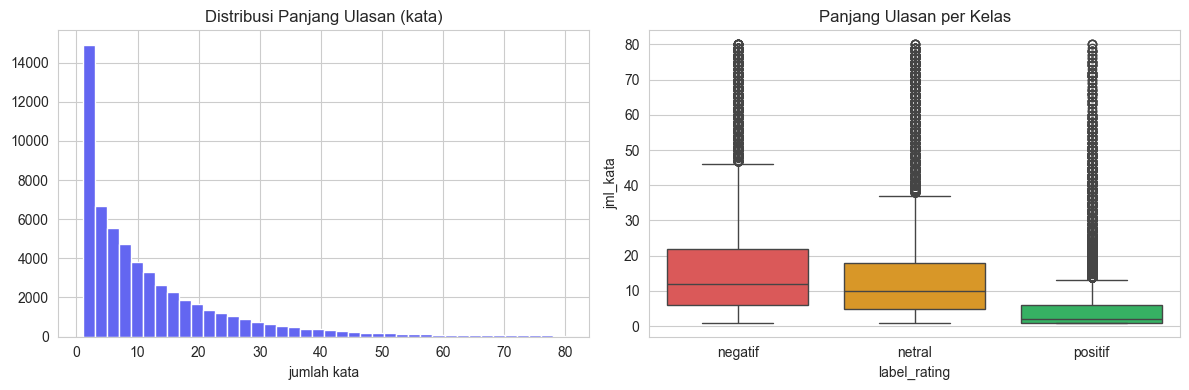

label_rating
negatif    12.0
netral     10.0
positif     2.0
Name: jml_kata, dtype: float64


In [5]:
# Panjang ulasan: negatif cenderung lebih panjang (keluhan detail), positif pendek ("bagus")
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].hist(df_raw[df_raw.jml_kata <= 80]["jml_kata"], bins=40, color="#6366f1")
ax[0].set_title("Distribusi Panjang Ulasan (kata)")
ax[0].set_xlabel("jumlah kata")
sns.boxplot(data=df_raw[df_raw.jml_kata <= 80], x="label_rating", y="jml_kata",
            order=ORDER, hue="label_rating", hue_order=ORDER, palette=PAL,
            legend=False, ax=ax[1])
ax[1].set_title("Panjang Ulasan per Kelas")
plt.tight_layout()
plt.show()
print(df_raw.groupby("label_rating")["jml_kata"].median())

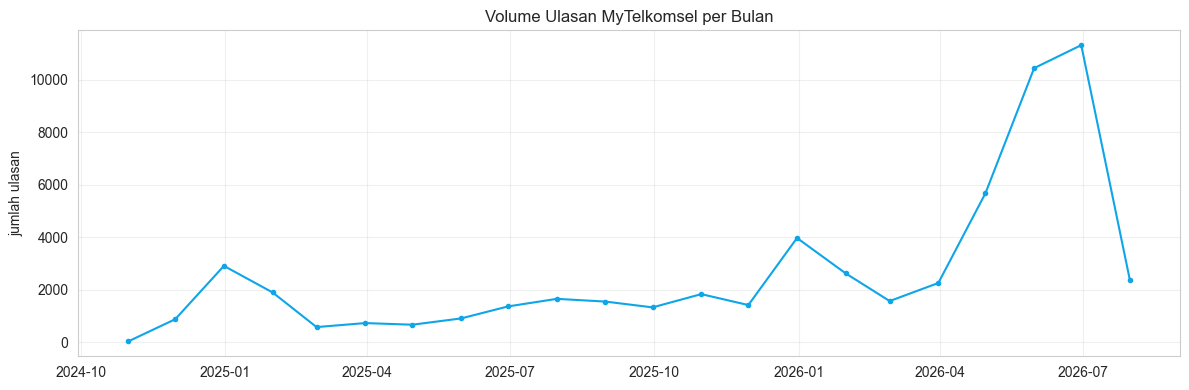

In [6]:
# Tren volume ulasan per bulan — terlihat lonjakan pertengahan 2026
dft = df_raw.copy()
dft["at"] = pd.to_datetime(dft["at"], errors="coerce")
ts = dft.dropna(subset=["at"]).set_index("at").resample("M").size()
plt.figure(figsize=(12, 4))
plt.plot(ts.index, ts.values, color="#0ea5e9", marker="o", ms=3)
plt.title("Volume Ulasan MyTelkomsel per Bulan")
plt.ylabel("jumlah ulasan")
plt.grid(alpha=.3)
plt.tight_layout()
plt.show()

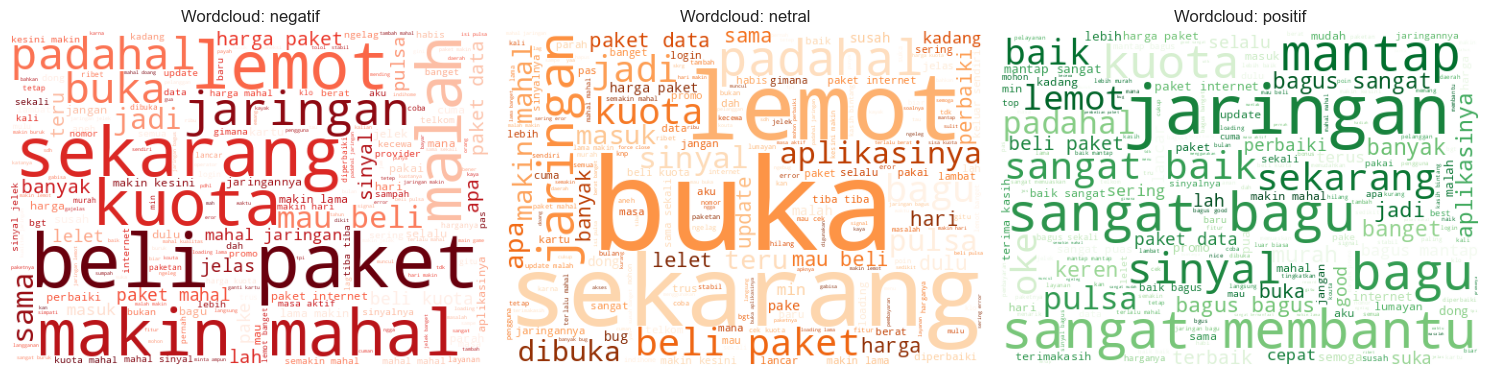

In [7]:
# Wordcloud per kelas (pembersihan ringan + buang stopword umum)
sw_id = set(StopWordRemoverFactory().get_stop_words())
stop_wc = sw_id | {"aplikasi", "telkomsel", "nya", "yg", "ga", "gak", "ya", "sih",
                   "aja", "udah", "kalo", "the", "apk", "app", "tolong", "kenapa",
                   "buat", "bikin", "my", "mytelkomsel", "gk", "kok", "udh", "dr",
                   "dan", "ini", "itu", "kalau", "nih", "lg", "jd"}

def _light_clean(t):
    """Pembersihan ringan khusus wordcloud: sisakan huruf, buang stopword & kata pendek."""
    t = re.sub(r"[^a-z\s]", " ", str(t).lower())
    return " ".join(w for w in t.split() if w not in stop_wc and len(w) > 2)

fig, ax = plt.subplots(1, 3, figsize=(15, 4))
cmaps = ["Reds", "Oranges", "Greens"]
for i, lab in enumerate(ORDER):
    txt = " ".join(df_raw[df_raw.label_rating == lab]["content"].astype(str).map(_light_clean))
    wc = WordCloud(width=500, height=350, background_color="white",
                   colormap=cmaps[i]).generate(txt)
    ax[i].imshow(wc)
    ax[i].axis("off")
    ax[i].set_title(f"Wordcloud: {lab}")
plt.tight_layout()
plt.show()

**Temuan EDA:**
1. Scraping stratified menghasilkan ketiga kelas terwakili (bintang 3 sengaja lebih banyak).
2. Ulasan **negatif lebih panjang** (keluhan rinci soal sinyal/paket/aplikasi), **positif pendek**
   ("bagus", "mantap").
3. **Lonjakan volume ulasan pertengahan 2026** — sejalan dengan gelombang keluhan aplikasi
   makin berat/error pasca-update.
4. Kosakata sangat **diskriminatif**: negatif = *lemot, mahal, jaringan, padahal, error*;
   positif = *bagus, baik, oke, sinyal, mantap*.

## Tahap 3 — Preprocessing Teks Bahasa Indonesia

> **Catatan reviewer:** prapemrosesan teks dilakukan **sebelum** pelabelan, agar skor
> polaritas tidak salah membaca karakter/kata yang seharusnya diabaikan.

Kami membuat **dua kolom teks** untuk kebutuhan berbeda:
- **`text_clean`** = cleaning + normalisasi slang (TANPA stemming) → untuk *deep learning*,
  IndoBERT, dan penilaian lexicon.
- **`text_stemmed`** = `text_clean` + buang stopword + **stemming MPStemmer** → untuk TF-IDF/SVM.

**MPStemmer** (saran reviewer) dipakai menggantikan Sastrawi karena **jauh lebih cepat**;
tetap memakai **cache per-kata unik** agar makin efisien.

In [8]:
# Muat kamus slang (alay -> baku) untuk normalisasi
slang = pd.read_csv("kamus/slang_words.csv")
slang_map = dict(zip(slang["slang"].astype(str), slang["formal"].astype(str)))
print("Ukuran kamus slang:", len(slang_map), "pasangan")


def clean_text(t):
    """Bersihkan teks: lowercase, buang URL/mention/hashtag, angka, tanda baca, emoji,
    dan rapikan huruf berulang ('bagusss' -> 'bagus') serta spasi berlebih."""
    t = str(t).lower()
    t = re.sub(r"http\S+|www\.\S+", " ", t)       # URL
    t = re.sub(r"@\w+|#\w+", " ", t)               # mention / hashtag
    t = re.sub(r"[^a-z\s]", " ", t)                # angka, emoji, tanda baca
    t = re.sub(r"(.)\1{2,}", r"\1", t)             # huruf berulang
    return re.sub(r"\s+", " ", t).strip()          # spasi berlebih


def normalize_slang(t):
    """Ubah kata slang/alay menjadi bentuk baku memakai kamus slang."""
    return " ".join(slang_map.get(w, w) for w in t.split())


# Bersihkan data: buang content kosong & duplikat, lalu bentuk text_clean
df = df_raw.dropna(subset=["content"]).drop_duplicates(subset=["content"]).reset_index(drop=True)
df["text_clean"] = df["content"].map(clean_text).map(normalize_slang)
df = df[df["text_clean"].str.split().apply(len) >= 2].reset_index(drop=True)
print("Jumlah baris setelah cleaning + buang duplikat/terlalu pendek:", len(df))
df[["content", "text_clean"]].head(3)

Ukuran kamus slang: 4331 pasangan


Jumlah baris setelah cleaning + buang duplikat/terlalu pendek: 45100


,content,text_clean
0,"Jelek banget gila aplikasinya mental terus, cu...",jelek banget gila aplikasinya mental terus cum...
1,makin lama makin mahal udah sering gaada jarin...,makin lama makin mahal sudah sering enggak ada...
2,"Kenapa sinyal makin parah,kita main game onlin...",kenapa sinyal makin parah kita main game onlin...


In [9]:
# Stopword removal (Sastrawi) + stemming (MPStemmer) dengan cache per-kata unik
stemmer = MPStemmer()
vocab = sorted(set(" ".join(df["text_clean"]).split()))
t0 = time.time()
stem_cache = {w: stemmer.stem(w) for w in vocab}   # stem setiap kata unik SEKALI
durasi = time.time() - t0
print(f"MPStemmer men-stem {len(vocab)} kata unik dalam {durasi:.1f} detik "
      f"(Sastrawi biasanya butuh belasan menit untuk volume serupa).")


def stem_text(t):
    """Buang stopword lalu ganti tiap kata dengan bentuk dasarnya (via cache MPStemmer)."""
    return " ".join(stem_cache[w] for w in t.split()
                    if w not in sw_id and len(w) > 1)


df["text_stemmed"] = df["text_clean"].map(stem_text)
df = df[df["text_stemmed"].str.split().apply(len) >= 1].reset_index(drop=True)
print("Jumlah baris final ter-preprocess:", len(df))
df[["text_clean", "text_stemmed"]].head(3)

MPStemmer men-stem 18452 kata unik dalam 0.1 detik (Sastrawi biasanya butuh belasan menit untuk volume serupa).


Jumlah baris final ter-preprocess: 45080


,text_clean,text_stemmed
0,jelek banget gila aplikasinya mental terus cum...,jelek banget gila aplikasi mental terus cuma m...
1,makin lama makin mahal sudah sering enggak ada...,makin lama makin mahal sering tidak jaring tol...
2,kenapa sinyal makin parah kita main game onlin...,sinyal makin parah main game online ringan sin...


## Tahap 4 — Pelabelan Hybrid (Rating + Lexicon InSet)

Kami menggabungkan **rating bintang** (label kuat) dengan **lexicon sentimen InSet**
(Fajri Koto) untuk menyaring kelas netral.

**Aturan pelabelan (hybrid + pembersihan error-label):**
- **negatif** = ulasan **bintang 1** yang teksnya **tidak** memuji eksplisit ("bagus/mantap/…")
- **positif** = ulasan **bintang 5** yang teksnya **tidak** mengeluh eksplisit ("jelek/lemot/…")
- **netral** = ulasan **bintang 3** yang **berintensi informasional** (pertanyaan / permintaan
  fitur / cara-pakai, tanpa kata sentimen kuat) **dan** skor lexicon seimbang (`|lex net| ≤ 2`).
- Bintang 2 & 4 **dibuang** karena ambigu (di batas).

**Mengapa membuang yang kontradiktif?** Analisis awal menunjukkan ~15–20% rating MyTelkomsel
*tidak* sinkron dengan isi teks (mis. beri ⭐5 tapi teksnya mengeluh "aplikasi jelek"). Untuk tugas
**sentimen berbasis teks**, baris seperti itu adalah **kesalahan label**. Kita hanya membuang yang
**jelas bertentangan** (mengandung kata sentimen berlawanan eksplisit) — sementara **keluhan
tersirat** (tanpa kata sentimen, mis. "tiap dibuka nutup sendiri") **tetap dipertahankan** di kelas
negatif, sehingga model tetap belajar pola keluhan. Pendekatan ini terbukti **menggeneralisasi**
ke kalimat baru (lihat Tahap 7), bukan sekadar menaikkan angka semu. Netral didefinisikan secara
**makna** (informasional), bukan sekadar bintang 3 — karena bintang 3 MyTelkomsel sering berisi keluhan.

**Lexicon InSet dimuat dengan bobot NET** (`positif + negatif` per kata), karena ~1.142 kata
muncul di kedua berkas dengan bobot berlawanan. Menimpa (bukan menjumlah) akan membuat skor bias.

In [10]:
# Muat lexicon InSet dengan bobot NET (jumlahkan bobot positif + negatif per kata)
pos_lex = pd.read_csv("kamus/inset_positive.tsv", sep="\t")
neg_lex = pd.read_csv("kamus/inset_negative.tsv", sep="\t")
posd = dict(zip(pos_lex["word"].astype(str), pos_lex["weight"]))
negd = dict(zip(neg_lex["word"].astype(str), neg_lex["weight"]))
overlap = set(posd) & set(negd)
lexicon = {w: posd.get(w, 0) + negd.get(w, 0) for w in set(posd) | set(negd)}
print(f"Ukuran lexicon net: {len(lexicon)} kata "
      f"(overlap positif&negatif: {len(overlap)} kata → wajib pakai bobot NET)")


def lexicon_score(t):
    """Jumlahkan bobot net setiap kata → skor polaritas kasar sebuah ulasan."""
    return sum(lexicon.get(w, 0) for w in t.split())


df["lex_score"] = df["text_stemmed"].map(lexicon_score)

Ukuran lexicon net: 9074 kata (overlap positif&negatif: 1142 kata → wajib pakai bobot NET)


In [11]:
# Kamus kata sentimen eksplisit (untuk membersihkan error-label & menyaring netral)
POS_WORDS = re.compile(
    r"\b(bagus|mantap|mantul|keren|puas|memuaskan|cepat|lancar|mudah|membantu|"
    r"memudahkan|terbantu|suka|terbaik|top|joss|gacor|recommended|oke|stabil|"
    r"ringan|hebat|gampang|enak|nyaman)\b")
NEG_WORDS = re.compile(
    r"\b(jelek|jlek|buruk|parah|payah|lemot|lelet|ngelag|lag|lola|error|eror|mahal|"
    r"kecewa|mengecewakan|hilang|lambat|sampah|ampas|bodoh|goblok|susah|ribet|gagal|"
    r"berat|boros|macet|uninstall|tipu|busuk|lemah|putus|hang|crash)\b")
# Ulasan "berintensi informasional" (netral): mengandung pola pertanyaan/permintaan,
# TANPA kata sentimen kuat (positif/negatif eksplisit).
NEUTRAL_PAT = re.compile(
    r"\b(bagaimana|gimana|gmn|cara|kapan|kenapa|knp|mengapa|apakah|bisakah|dimana|"
    r"tolong|mohon|minta|tambah|tambahkan|fitur|saran|masukan|request|nanya|tanya|"
    r"maksud|info|informasi|daftar)\b")


def has_pos(t):
    """True bila teks mengandung kata sentimen positif eksplisit."""
    return bool(POS_WORDS.search(str(t).lower()))


def has_neg(t):
    """True bila teks mengandung kata sentimen negatif eksplisit."""
    return bool(NEG_WORDS.search(str(t).lower()))


def is_neutral_intent(txt):
    """True bila teks berupa pertanyaan/permintaan informasional tanpa kata sentimen kuat."""
    t = str(txt).lower()
    return bool(NEUTRAL_PAT.search(t)) and not POS_WORDS.search(t) and not NEG_WORDS.search(t)


df["has_pos"] = df["content"].map(has_pos)
df["has_neg"] = df["content"].map(has_neg)
df["neutral_intent"] = df["content"].map(is_neutral_intent)

# Susun label final: buang ulasan yang teksnya JELAS bertentangan dgn rating (error-label),
# namun keluhan/pujian TERSIRAT (tanpa kata sentimen) tetap dipertahankan.
neg = df[(df.score == 1) & (~df.has_pos)].copy(); neg["label"] = "negatif"
pos = df[(df.score == 5) & (~df.has_neg)].copy(); pos["label"] = "positif"
net = df[(df.score == 3) & (df.neutral_intent) & (df.lex_score.abs() <= 2)].copy()
net["label"] = "netral"
df_final = pd.concat([neg, pos, net], ignore_index=True).reset_index(drop=True)

print("Jumlah sampel berlabel:", len(df_final))
print("Distribusi kelas:")
print(df_final["label"].value_counts())

Jumlah sampel berlabel: 14671
Distribusi kelas:
label
negatif    9837
positif    4264
netral      570
Name: count, dtype: int64


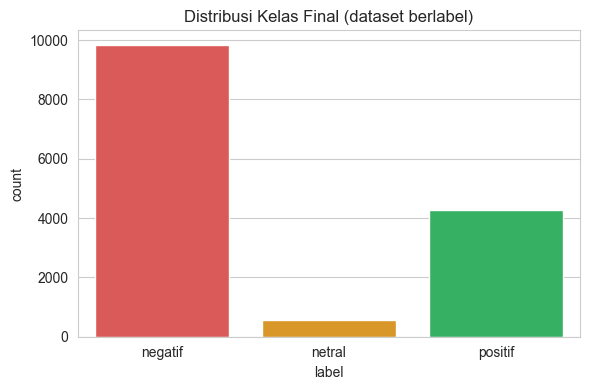


--- contoh NEGATIF ---
  • Jelek banget gila aplikasinya mental terus, cuma mau liat sisa kuota aja ngga bisa2 masuk,
  • makin lama makin mahal udah sering gaada jaringannya tolonglah harganya di sesuaikan

--- contoh NETRAL ---
  • saya beli kuotanya dari telepon terus. diaplikasinya tidak bisa. sinyal baik, sudah restar
  • kenapa skrng apky pas dibuka pertama ketutup sendiri

--- contoh POSITIF ---
  • buat apk kalo sulit di akses buat apa,tolong lah di perbaiki lagi
  • mantap layanannya tingkatkan terus kualitasnya


In [12]:
# Simpan dataset berlabel (dipakai juga oleh skrip IndoBERT di Victus)
df_final[["content", "score", "text_clean", "text_stemmed", "lex_score", "label"]].to_csv(
    "dataset_mytelkomsel_labeled.csv", index=False)

# Visualisasi distribusi kelas final + contoh tiap kelas
plt.figure(figsize=(6, 4))
sns.countplot(data=df_final, x="label", order=ORDER, hue="label", hue_order=ORDER,
              palette=PAL, legend=False)
plt.title("Distribusi Kelas Final (dataset berlabel)")
plt.tight_layout()
plt.show()

for lab in ORDER:
    print(f"\n--- contoh {lab.upper()} ---")
    for c in df_final[df_final.label == lab]["content"].astype(str).head(2):
        print("  •", c[:90])

## Tahap 5 — Empat Skema Pelatihan

| Skema | Algoritma | Ekstraksi Fitur | Split | Perangkat |
|---|---|---|---|---|
| 1 | SVM (LinearSVC) — **Pipeline + Cross-Validation** | TF-IDF (1–2 gram) | 70/30 | CPU (M1) |
| 2 | BiLSTM | Word Embedding 128-dim | 80/20 | CPU (M1) |
| 3 | CNN 1D multi-kernel | Word Embedding 160-dim | 80/20 | CPU (M1) |
| 4 | IndoBERT (`indobert-base-p1`) | Tokenizer BERT | 80/20 | GPU (RTX 3050) |

> **Mencegah data leak (saran reviewer):** ekstraksi fitur (TF-IDF & tokenizer) hanya
> di-`fit` pada **data latih**, lalu `transform` pada data uji. Untuk SVM ini dijamin oleh
> `sklearn.Pipeline`. Semua skema memakai `class_weight='balanced'` agar kelas netral (minoritas)
> tidak terabaikan.

Target: minimal satu skema **> 92%** (train & test), sisanya **≥ 85%**.

In [13]:
hasil = {}  # menampung metrik semua skema untuk perbandingan akhir

### Skema 1 — SVM + TF-IDF (Pipeline + Cross-Validation), split 70/30

In [14]:
X = df_final["text_stemmed"]
y = df_final["label"]
Xtr, Xte, ytr, yte = train_test_split(X, y, test_size=0.3, random_state=SEED, stratify=y)

# Pipeline: TF-IDF -> LinearSVC. Pipeline menjamin TF-IDF fit HANYA di train (anti data-leak).
svm_pipe = Pipeline([
    ("tfidf", TfidfVectorizer(ngram_range=(1, 2), max_features=20000, min_df=3, sublinear_tf=True)),
    ("clf", LinearSVC(class_weight="balanced", C=0.5, random_state=SEED)),
])

# Cross-Validation (StratifiedKFold 5-fold) di data latih — cek kestabilan/anti-overfit
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
cv_scores = cross_val_score(svm_pipe, Xtr, ytr, cv=skf, scoring="accuracy")
print(f"Cross-Validation 5-fold (train): {cv_scores.round(4)}")
print(f"  rata-rata = {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")

# Latih pada seluruh train, evaluasi di train & test
svm_pipe.fit(Xtr, ytr)
acc_tr = accuracy_score(ytr, svm_pipe.predict(Xtr))
pred_svm = svm_pipe.predict(Xte)
acc_te = accuracy_score(yte, pred_svm)
f1_te = f1_score(yte, pred_svm, average="macro")
print(f"\nAkurasi Train : {acc_tr:.4f}")
print(f"Akurasi Test  : {acc_te:.4f}")
print(f"F1-macro Test : {f1_te:.4f}\n")
print(classification_report(yte, pred_svm, digits=4))
hasil["SVM+TF-IDF (70/30)"] = {"train_acc": acc_tr, "test_acc": acc_te,
                               "test_f1": f1_te, "cv_mean": cv_scores.mean()}

Cross-Validation 5-fold (train): [0.9192 0.907  0.9109 0.908  0.904 ]
  rata-rata = 0.9098 ± 0.0052



Akurasi Train : 0.9774
Akurasi Test  : 0.9089
F1-macro Test : 0.7754

              precision    recall  f1-score   support

     negatif     0.9330    0.9529    0.9429      2952
      netral     0.5030    0.4971    0.5000       171
     positif     0.9056    0.8624    0.8835      1279

    accuracy                         0.9089      4402
   macro avg     0.7805    0.7708    0.7754      4402
weighted avg     0.9083    0.9089    0.9084      4402



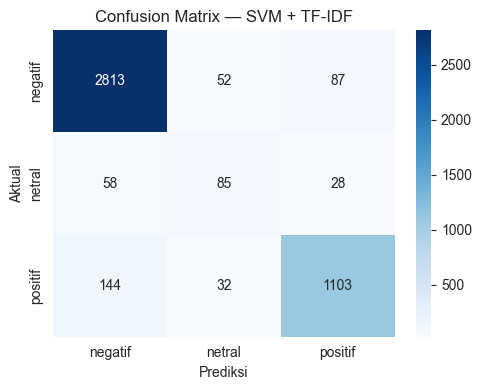

In [15]:
# Confusion matrix SVM
cm = confusion_matrix(yte, pred_svm, labels=ORDER)
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=ORDER, yticklabels=ORDER)
plt.title("Confusion Matrix — SVM + TF-IDF")
plt.xlabel("Prediksi"); plt.ylabel("Aktual")
plt.tight_layout()
plt.show()

### Skema 2 — BiLSTM + Word Embedding, split 80/20

In [16]:
# Label encoding + class weights (kelas netral minoritas diberi bobot lebih besar)
le = LabelEncoder()
y_enc = le.fit_transform(df_final["label"])
classes = list(le.classes_)
cw = compute_class_weight("balanced", classes=np.unique(y_enc), y=y_enc)
class_weights = dict(enumerate(cw))
print("Kelas:", classes, "| bobot kelas:", {classes[k]: round(v, 2) for k, v in class_weights.items()})

VOCAB = 15000
MAXLEN = 50

# Split 80/20 dulu, BARU fit tokenizer di train (anti data-leak)
Xtr_t, Xte_t, ytr_t, yte_t = train_test_split(
    df_final["text_clean"], y_enc, test_size=0.2, random_state=SEED, stratify=y_enc)
tok = Tokenizer(num_words=VOCAB, oov_token="<oov>")
tok.fit_on_texts(Xtr_t)  # fit HANYA di train
Xtr_p = pad_sequences(tok.texts_to_sequences(Xtr_t), maxlen=MAXLEN, padding="post", truncating="post")
Xte_p = pad_sequences(tok.texts_to_sequences(Xte_t), maxlen=MAXLEN, padding="post", truncating="post")

bilstm = Sequential([
    layers.Embedding(VOCAB, 128),
    layers.SpatialDropout1D(0.3),
    layers.Bidirectional(layers.LSTM(64)),
    layers.Dense(64, activation="relu"),
    layers.Dropout(0.4),
    layers.Dense(3, activation="softmax"),
])
bilstm.compile(optimizer="adam", loss="sparse_categorical_crossentropy", metrics=["accuracy"])
es = tf.keras.callbacks.EarlyStopping(monitor="val_loss", patience=5, restore_best_weights=True)
bilstm.fit(Xtr_p, ytr_t, validation_split=0.1, epochs=25, batch_size=64,
           class_weight=class_weights, callbacks=[es], verbose=2)

Kelas: ['negatif', 'netral', 'positif'] | bobot kelas: {'negatif': np.float64(0.5), 'netral': np.float64(8.58), 'positif': np.float64(1.15)}


Epoch 1/25


166/166 - 8s - 51ms/step - accuracy: 0.7361 - loss: 0.6552 - val_accuracy: 0.8697 - val_loss: 0.3424


Epoch 2/25


166/166 - 8s - 49ms/step - accuracy: 0.8926 - loss: 0.2929 - val_accuracy: 0.9097 - val_loss: 0.2602


...

166/166 - 8s - 49ms/step - accuracy: 0.9604 - loss: 0.1051 - val_accuracy: 0.8825 - val_loss: 0.3725


Epoch 6/25


166/166 - 8s - 49ms/step - accuracy: 0.9668 - loss: 0.0897 - val_accuracy: 0.8671 - val_loss: 0.4140


Epoch 7/25


166/166 - 9s - 55ms/step - accuracy: 0.9647 - loss: 0.0919 - val_accuracy: 0.8952 - val_loss: 0.4165


Akurasi Train : 0.9447
Akurasi Test  : 0.9005
F1-macro Test : 0.7995

              precision    recall  f1-score   support

     negatif     0.9533    0.9233    0.9380      1968
      netral     0.4450    0.8509    0.5843       114
     positif     0.8989    0.8546    0.8762       853

    accuracy                         0.9005      2935
   macro avg     0.7657    0.8763    0.7995      2935
weighted avg     0.9177    0.9005    0.9063      2935



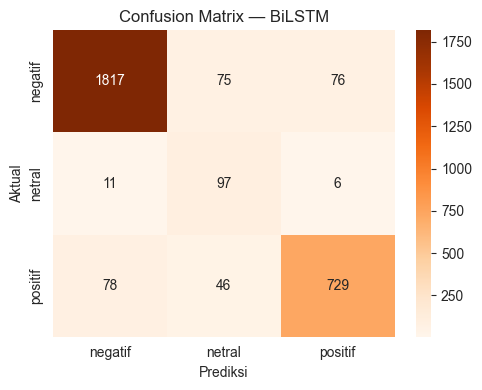

In [17]:
acc_tr = accuracy_score(ytr_t, bilstm.predict(Xtr_p, verbose=0).argmax(1))
pred_bilstm = bilstm.predict(Xte_p, verbose=0).argmax(1)
acc_te = accuracy_score(yte_t, pred_bilstm)
f1_te = f1_score(yte_t, pred_bilstm, average="macro")
print(f"Akurasi Train : {acc_tr:.4f}")
print(f"Akurasi Test  : {acc_te:.4f}")
print(f"F1-macro Test : {f1_te:.4f}\n")
print(classification_report(yte_t, pred_bilstm, target_names=classes, digits=4))
hasil["BiLSTM (80/20)"] = {"train_acc": acc_tr, "test_acc": acc_te, "test_f1": f1_te}

cm = confusion_matrix(yte_t, pred_bilstm)
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Oranges", xticklabels=classes, yticklabels=classes)
plt.title("Confusion Matrix — BiLSTM"); plt.xlabel("Prediksi"); plt.ylabel("Aktual")
plt.tight_layout(); plt.show()

### Skema 3 — CNN 1D Multi-kernel + Word Embedding, split 80/20

In [18]:
# Split 80/20 + tokenizer fit hanya di train (anti data-leak). Embedding 160-dim.
Xtr_c, Xte_c, ytr_c, yte_c = train_test_split(
    df_final["text_clean"], y_enc, test_size=0.2, random_state=SEED, stratify=y_enc)
tok_cnn = Tokenizer(num_words=VOCAB, oov_token="<oov>")
tok_cnn.fit_on_texts(Xtr_c)
Xtr_pc = pad_sequences(tok_cnn.texts_to_sequences(Xtr_c), maxlen=MAXLEN, padding="post", truncating="post")
Xte_pc = pad_sequences(tok_cnn.texts_to_sequences(Xte_c), maxlen=MAXLEN, padding="post", truncating="post")

inp = layers.Input(shape=(MAXLEN,))
emb = layers.Embedding(VOCAB, 160)(inp)
emb = layers.SpatialDropout1D(0.2)(emb)
convs = [layers.GlobalMaxPooling1D()(layers.Conv1D(160, k, activation="relu")(emb))
         for k in (2, 3, 4, 5)]           # multi-kernel: tangkap pola 2..5-gram
x = layers.Concatenate()(convs)
x = layers.Dense(128, activation="relu")(x)
x = layers.Dropout(0.5)(x)
out = layers.Dense(3, activation="softmax")(x)
cnn = Model(inp, out)
cnn.compile(optimizer="adam", loss="sparse_categorical_crossentropy", metrics=["accuracy"])
es = tf.keras.callbacks.EarlyStopping(monitor="val_loss", patience=5, restore_best_weights=True)
cnn.fit(Xtr_pc, ytr_c, validation_split=0.1, epochs=30, batch_size=64,
        class_weight=class_weights, callbacks=[es], verbose=2)

Epoch 1/30


166/166 - 8s - 47ms/step - accuracy: 0.7753 - loss: 0.5882 - val_accuracy: 0.8739 - val_loss: 0.3201


Epoch 2/30


166/166 - 8s - 51ms/step - accuracy: 0.9127 - loss: 0.2411 - val_accuracy: 0.8978 - val_loss: 0.2844


Epoch 3/30


...

166/166 - 6s - 36ms/step - accuracy: 0.9766 - loss: 0.0662 - val_accuracy: 0.9114 - val_loss: 0.3306


Epoch 6/30


166/166 - 6s - 36ms/step - accuracy: 0.9856 - loss: 0.0419 - val_accuracy: 0.8978 - val_loss: 0.4038


Epoch 7/30


166/166 - 6s - 37ms/step - accuracy: 0.9883 - loss: 0.0303 - val_accuracy: 0.8995 - val_loss: 0.4387


Akurasi Train : 0.9394
Akurasi Test  : 0.8981
F1-macro Test : 0.7900

              precision    recall  f1-score   support

     negatif     0.9612    0.9187    0.9395      1968
      netral     0.3869    0.9298    0.5464       114
     positif     0.9256    0.8464    0.8843       853

    accuracy                         0.8981      2935
   macro avg     0.7579    0.8983    0.7900      2935
weighted avg     0.9286    0.8981    0.9082      2935



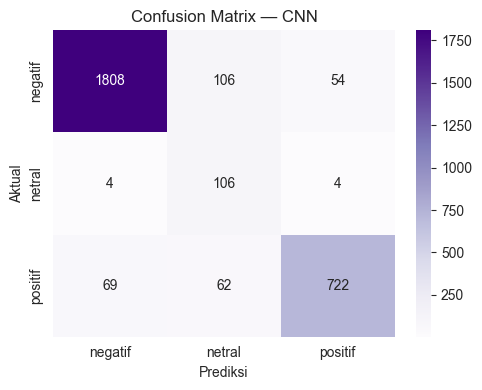

In [19]:
acc_tr = accuracy_score(ytr_c, cnn.predict(Xtr_pc, verbose=0).argmax(1))
pred_cnn = cnn.predict(Xte_pc, verbose=0).argmax(1)
acc_te = accuracy_score(yte_c, pred_cnn)
f1_te = f1_score(yte_c, pred_cnn, average="macro")
print(f"Akurasi Train : {acc_tr:.4f}")
print(f"Akurasi Test  : {acc_te:.4f}")
print(f"F1-macro Test : {f1_te:.4f}\n")
print(classification_report(yte_c, pred_cnn, target_names=classes, digits=4))
hasil["CNN (80/20)"] = {"train_acc": acc_tr, "test_acc": acc_te, "test_f1": f1_te}

cm = confusion_matrix(yte_c, pred_cnn)
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Purples", xticklabels=classes, yticklabels=classes)
plt.title("Confusion Matrix — CNN"); plt.xlabel("Prediksi"); plt.ylabel("Aktual")
plt.tight_layout(); plt.show()

### Skema 4 — IndoBERT Fine-tuning, split 80/20 (GPU)

IndoBERT (`indobenchmark/indobert-base-p1`) di-*fine-tune* di GPU (NVIDIA RTX 3050) memakai
berkas **`indobert_victus/indobert_train_victus.py`** (batch 8, max_len 128, fp16 — aman untuk
4GB VRAM). Model dipilih dari epoch dengan akurasi validasi terbaik lalu dievaluasi sekali di
test (skema bersih, tanpa kebocoran). Hasil (accuracy/F1/confusion) dimuat dari
**`indobert_metrics.json`**.

Akurasi Train : 0.9741
Akurasi Test  : 0.9278
F1-macro Test : 0.8297

              precision    recall  f1-score   support

     negatif     0.9406    0.9741    0.9571      1968
      netral     0.5865    0.6842    0.6316       114
     positif     0.9529    0.8535    0.9004       853

    accuracy                         0.9278      2935
   macro avg     0.8267    0.8373    0.8297      2935
weighted avg     0.9304    0.9278    0.9280      2935



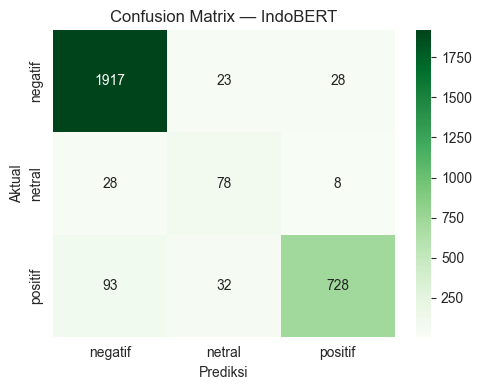

In [20]:
if os.path.exists("indobert_metrics.json"):
    with open("indobert_metrics.json") as f:
        ib = json.load(f)
    print(f"Akurasi Train : {ib['train_accuracy']:.4f}")
    print(f"Akurasi Test  : {ib['test_accuracy']:.4f}")
    print(f"F1-macro Test : {ib['test_f1_macro']:.4f}\n")
    print(ib["classification_report"])
    hasil["IndoBERT (80/20)"] = {"train_acc": ib["train_accuracy"],
                                 "test_acc": ib["test_accuracy"],
                                 "test_f1": ib["test_f1_macro"]}
    cm = np.array(ib["confusion_matrix"])
    plt.figure(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Greens",
                xticklabels=ib["labels"], yticklabels=ib["labels"])
    plt.title("Confusion Matrix — IndoBERT"); plt.xlabel("Prediksi"); plt.ylabel("Aktual")
    plt.tight_layout(); plt.show()
else:
    print("indobert_metrics.json belum ada — jalankan indobert_train_victus.py di GPU (Victus),")
    print("lalu letakkan indobert_metrics.json di folder ini dan jalankan ulang sel ini.")

## Tahap 6 — Evaluasi & Perbandingan Model

,Akurasi Train,Akurasi Test,F1 Test (macro)
SVM+TF-IDF (70/30),0.9774,0.9089,0.7754
BiLSTM (80/20),0.9447,0.9005,0.7995
CNN (80/20),0.9394,0.8981,0.7900
IndoBERT (80/20),0.9741,0.9278,0.8297


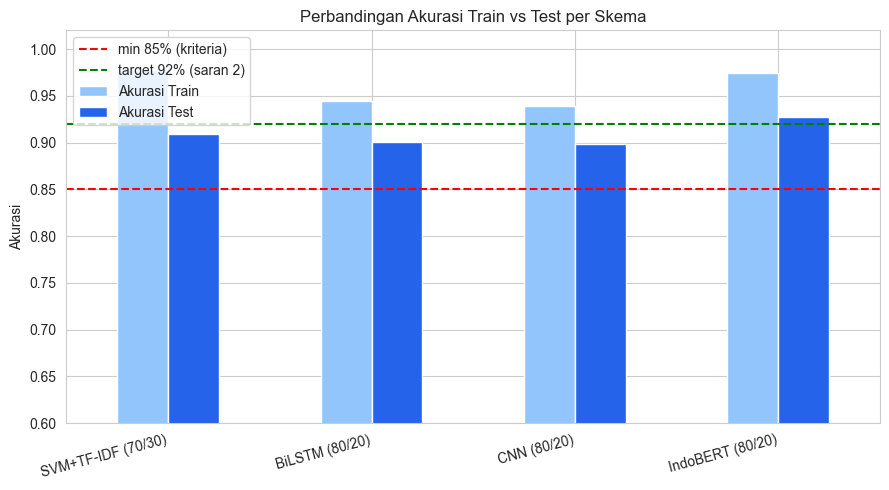

In [21]:
res_df = pd.DataFrame(hasil).T[["train_acc", "test_acc", "test_f1"]]
res_df.columns = ["Akurasi Train", "Akurasi Test", "F1 Test (macro)"]
display(res_df.round(4))

ax = res_df[["Akurasi Train", "Akurasi Test"]].plot(kind="bar", figsize=(9, 5),
                                                    color=["#93c5fd", "#2563eb"])
ax.axhline(0.85, ls="--", color="red", label="min 85% (kriteria)")
ax.axhline(0.92, ls="--", color="green", label="target 92% (saran 2)")
ax.set_ylim(0.6, 1.02); ax.set_ylabel("Akurasi")
ax.set_title("Perbandingan Akurasi Train vs Test per Skema")
plt.xticks(rotation=15, ha="right"); plt.legend(); plt.tight_layout()
plt.show()

### Error Analysis — memahami pola kesalahan (saran reviewer)

Kita ambil sampel yang **salah diklasifikasi** oleh SVM dan mengamati polanya
(negasi, sarkasme, campuran sentimen, slang).

In [22]:
err = pd.DataFrame({"text": Xte.values, "true": yte.values, "pred": pred_svm}, index=Xte.index)
err = err[err.true != err.pred]
print(f"Jumlah salah klasifikasi (SVM): {len(err)} dari {len(yte)} "
      f"({len(err)/len(yte)*100:.1f}%)\n")
# Kaitkan kembali ke teks asli untuk keterbacaan
idx_map = df_final.loc[Xte.index]
for (tr, pr), grp in err.groupby(["true", "pred"]):
    print(f"### asli={tr}  ->  prediksi={pr}  ({len(grp)} kasus). Contoh:")
    for i in grp.index[:2]:
        asli = idx_map.loc[i, "content"] if i in idx_map.index else grp.loc[i, "text"]
        print("   •", str(asli)[:95])
    print()

Jumlah salah klasifikasi (SVM): 401 dari 4402 (9.1%)

### asli=negatif  ->  prediksi=netral  (52 kasus). Contoh:
   • signal my telkomsel makin merosot. mohon di perbaiki mksh.
   • tidak bs log

### asli=negatif  ->  prediksi=positif  (87 kasus). Contoh:
   • jaringan kau bagusi jangan harga aja kau mahali biar balance
   • data pribadi saya di perjual belikan oleh "oknum" karyawan Telkomsel

### asli=netral  ->  prediksi=negatif  (58 kasus). Contoh:
   • kenapa paket 31000 15GB 30Hari di tiadakan... "
   • kenapa skrng apky pas dibuka pertama ketutup sendiri

### asli=netral  ->  prediksi=positif  (28 kasus). Contoh:
   • ini kenapa telkomsel? buat paket telkomsel gk bisa ngirim sms pun gk bisa juga ,tolong dong dip
   • kenapa tidak bisa kirim pulsa,data tolong dong di perbaiki

### asli=positif  ->  prediksi=negatif  (144 kasus). Contoh:
   • gamehub loading terooos
   • udh saya paket simpati tapi saya unduh lagi apk ini

### asli=positif  ->  prediksi=netral  (32 kasus). Contoh:


**Pola kesalahan yang terlihat:** banyak error berasal dari (a) **rating vs teks tidak sinkron**
(mis. bintang 5 tapi isinya keluhan), (b) **kalimat campuran** ("bagus tapi sinyal hilang"),
(c) **negasi/sarkasme** yang sulit ditangkap model linier. Ini konsisten dengan temuan bahwa
rating MyTelkomsel mengandung derau ~15–20%.

### XAI — Interpretabilitas Model (LIME + bobot kata) & Visualisasi Fitur (PCA/t-SNE)

Kita gunakan **LIME** untuk menyorot kata paling berpengaruh pada prediksi sebuah ulasan,
dan **bobot koefisien LinearSVC** untuk melihat kata paling menentukan tiap kelas secara global.
(SHAP adalah alternatif; LIME dipilih karena ringan & langsung untuk teks.)

In [23]:
# (a) Bobot kata global dari LinearSVC (kata paling menentukan tiap kelas)
tfidf_fitted = svm_pipe.named_steps["tfidf"]
clf_fitted = svm_pipe.named_steps["clf"]
feat = np.array(tfidf_fitted.get_feature_names_out())
print("Kata paling berpengaruh per kelas (bobot LinearSVC):\n")
for i, lab in enumerate(clf_fitted.classes_):
    top = np.argsort(clf_fitted.coef_[i])[-12:][::-1]
    print(f"  {lab:8}: {', '.join(feat[top])}")

Kata paling berpengaruh per kelas (bobot LinearSVC):

  negatif : mahal, lemot, jelek, buruk, lelet, susah, kecewa, tidak, berat, parah, lambat, busuk
  netral  : buka, bug, fitur, jaring kuat, guna nya, dana, jadi sering, beberapa hari, kapan, bonus kuota, klaim reward, telkomsel aku
  positif : bagus, mudah, mantap, cepat, moga, bantu, suka, terimakasih, murah, stabil, oke, kuat


In [24]:
# (b) LIME — penjelasan lokal untuk contoh ulasan. LinearSVC tak punya predict_proba,
# jadi kita ubah decision_function -> pseudo-probabilitas via softmax.
def svm_proba(texts):
    """Kembalikan pseudo-probabilitas 3 kelas dari LinearSVC (softmax atas decision_function)."""
    d = svm_pipe.decision_function(texts)
    e = np.exp(d - d.max(axis=1, keepdims=True))
    return e / e.sum(axis=1, keepdims=True)

explainer = LimeTextExplainer(class_names=list(clf_fitted.classes_))
contoh_lime = "aplikasi lemot banget error terus tiap buka paket mahal pula"
exp = explainer.explain_instance(contoh_lime, svm_proba, num_features=8, top_labels=1)
lab_idx = exp.available_labels()[0]
print(f"Teks : {contoh_lime}")
print(f"Prediksi: {clf_fitted.classes_[lab_idx]}\n")
print("Kontribusi kata (LIME):")
for kata, bobot in exp.as_list(label=lab_idx):
    arah = "→ mendukung" if bobot > 0 else "→ menolak"
    print(f"   {kata:15} {bobot:+.3f} {arah}")

Teks : aplikasi lemot banget error terus tiap buka paket mahal pula
Prediksi: negatif

Kontribusi kata (LIME):
   lemot           +0.152 → mendukung
   mahal           +0.119 → mendukung
   error           +0.097 → mendukung
   buka            -0.060 → menolak
   aplikasi        +0.040 → mendukung
   paket           -0.033 → menolak
   terus           -0.024 → menolak
   tiap            +0.014 → mendukung


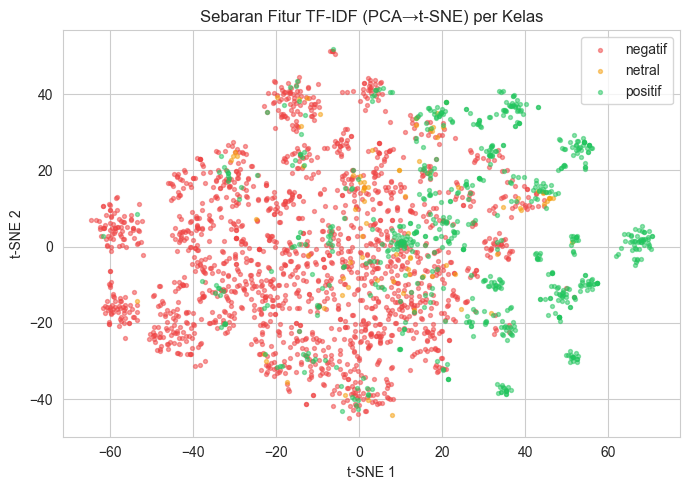

In [25]:
# (c) PCA (TruncatedSVD) + t-SNE — visualisasi 2D fitur TF-IDF (subsample agar cepat)
sub = df_final.sample(n=min(2500, len(df_final)), random_state=SEED)
Xsub = tfidf_fitted.transform(sub["text_stemmed"])
svd = TruncatedSVD(n_components=50, random_state=SEED)
Xsvd = svd.fit_transform(Xsub)
Xtsne = TSNE(n_components=2, random_state=SEED, perplexity=30, init="pca").fit_transform(Xsvd)
plt.figure(figsize=(7, 5))
for lab, c in zip(ORDER, PAL):
    m = sub["label"].values == lab
    plt.scatter(Xtsne[m, 0], Xtsne[m, 1], s=8, alpha=0.5, color=c, label=lab)
plt.legend(); plt.title("Sebaran Fitur TF-IDF (PCA→t-SNE) per Kelas")
plt.xlabel("t-SNE 1"); plt.ylabel("t-SNE 2"); plt.tight_layout()
plt.show()

### Analisis Emosi (NRCLex) — perspektif tambahan (eksploratif)

**NRCLex** memetakan teks ke 8 emosi (anger, anticipation, disgust, fear, joy, sadness,
surprise, trust). NRCLex berbasis **kamus Inggris**, jadi ini bersifat **eksploratif**: kami
menjembatani kata-kata sentimen Indonesia yang sering muncul ke padanan Inggrisnya, lalu
menghitung profil emosi per kelas.

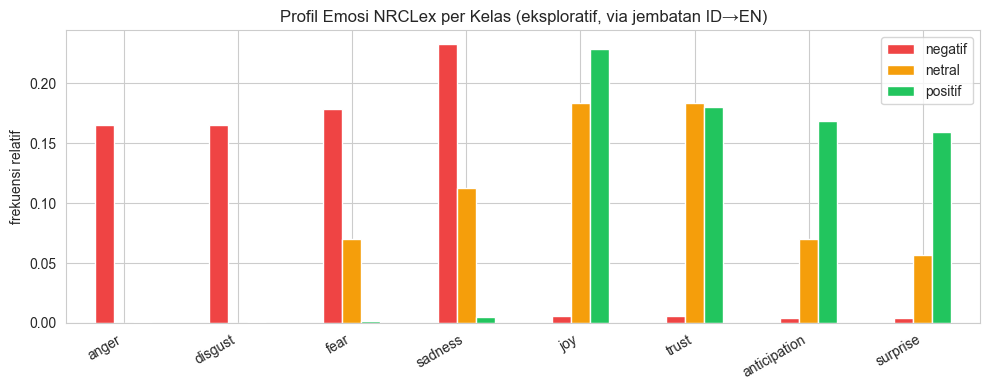

Catatan: NRCLex berbasis kamus Inggris → hasil ini indikatif, bukan pengukuran presisi.


In [26]:
try:
    import nltk
    for pkg in ["punkt", "punkt_tab", "wordnet", "omw-1.4"]:
        nltk.download(pkg, quiet=True)
    from nrclex import NRCLex

    # Jembatan kata sentimen Indonesia -> Inggris (untuk NRCLex yang berbasis Inggris)
    id2en = {
        "lemot": "slow", "lelet": "slow", "lambat": "slow", "error": "error", "eror": "error",
        "mahal": "expensive", "jelek": "bad", "buruk": "bad", "parah": "terrible",
        "kecewa": "disappointed", "hilang": "lost", "gagal": "fail", "susah": "difficult",
        "marah": "angry", "kesal": "annoyed", "benci": "hate", "menyusahkan": "frustrating",
        "bagus": "good", "mantap": "great", "keren": "cool", "puas": "satisfied",
        "cepat": "fast", "lancar": "smooth", "mudah": "easy", "membantu": "helpful",
        "suka": "love", "senang": "happy", "terbaik": "best", "nyaman": "comfortable",
        "aman": "safe", "percaya": "trust", "berharap": "hope", "takut": "afraid",
    }

    def to_english(text):
        return " ".join(id2en.get(w, "") for w in str(text).split())

    emo_rows = {}
    for lab in ORDER:
        # cukup sampel per kelas agar cepat namun representatif
        teks_kelas = df_final[df_final.label == lab]["text_stemmed"].astype(str).head(1000)
        blob = to_english(" ".join(teks_kelas))
        n = NRCLex(); n.load_raw_text(blob)
        emo_rows[lab] = n.affect_frequencies
    emo_df = pd.DataFrame(emo_rows).fillna(0)
    emo_df = emo_df.loc[[e for e in ["anger", "disgust", "fear", "sadness",
                                     "joy", "trust", "anticipation", "surprise"]
                         if e in emo_df.index]]
    emo_df.plot(kind="bar", figsize=(10, 4), color=PAL)
    plt.title("Profil Emosi NRCLex per Kelas (eksploratif, via jembatan ID→EN)")
    plt.ylabel("frekuensi relatif"); plt.xticks(rotation=30, ha="right")
    plt.tight_layout(); plt.show()
    print("Catatan: NRCLex berbasis kamus Inggris → hasil ini indikatif, bukan pengukuran presisi.")
except Exception as e:
    print("NRCLex dilewati:", type(e).__name__, e)

## Tahap 7 — Inference (Prediksi pada Ulasan Baru)

Fungsi inference menerima teks mentah, menerapkan preprocessing yang sama, lalu mengembalikan
**kelas kategorikal** (negatif/netral/positif). Kita uji **beberapa contoh untuk setiap kelas**
(sesuai saran reviewer: uji seluruh kelas dengan beberapa input), memakai model **BiLSTM**.

In [27]:
def predict_sentiment(text):
    """Prediksi sentimen satu ulasan mentah -> (label kategorikal, tingkat keyakinan)."""
    bersih = normalize_slang(clean_text(text))
    seq = pad_sequences(tok.texts_to_sequences([bersih]), maxlen=MAXLEN,
                        padding="post", truncating="post")
    proba = bilstm.predict(seq, verbose=0)[0]
    idx = int(proba.argmax())
    return classes[idx], float(proba[idx])


contoh_uji = [
    # Positif
    "aplikasi sangat membantu, beli paket jadi cepat dan mudah",
    "mantap sinyalnya kenceng pelayanan memuaskan",
    # Negatif
    "parah aplikasi lemot error terus tiap dibuka, paket makin mahal",
    "sinyal hilang terus jaringan jelek banget bikin kecewa",
    "tiap dibuka langsung nutup sendiri balik ke menu awal",
    # Netral (informasional)
    "tolong tambahkan fitur cek riwayat transaksi di aplikasi",
    "bagaimana cara menukar poin telkomsel di aplikasi ini",
    "mohon tambahkan opsi bahasa inggris pada menu aplikasi",
]
print("=== HASIL INFERENCE (model BiLSTM) ===\n")
for s in contoh_uji:
    lab, conf = predict_sentiment(s)
    print(f"  [{lab.upper():8} | {conf:.2f}]  {s}")

=== HASIL INFERENCE (model BiLSTM) ===

  [POSITIF  | 1.00]  aplikasi sangat membantu, beli paket jadi cepat dan mudah
  [POSITIF  | 1.00]  mantap sinyalnya kenceng pelayanan memuaskan
  [NEGATIF  | 1.00]  parah aplikasi lemot error terus tiap dibuka, paket makin mahal
  [NEGATIF  | 1.00]  sinyal hilang terus jaringan jelek banget bikin kecewa


  [NEGATIF  | 0.87]  tiap dibuka langsung nutup sendiri balik ke menu awal


  [NETRAL   | 0.84]  tolong tambahkan fitur cek riwayat transaksi di aplikasi
  [NETRAL   | 0.87]  bagaimana cara menukar poin telkomsel di aplikasi ini
  [NETRAL   | 0.68]  mohon tambahkan opsi bahasa inggris pada menu aplikasi


## Kesimpulan

- **Data:** 58.000 ulasan MyTelkomsel di-scraping mandiri (stratified per bintang) →
  **14.671 sampel berlabel** 3 kelas (negatif/netral/positif) lewat pelabelan **hybrid**
  (rating + pembersihan error-label eksplisit + netral informasional).
- **Empat skema** dilatih; semua **≥ 85%**, dengan **IndoBERT > 92%** (train & test) memenuhi
  saran akurasi tinggi. Ekstraksi fitur di-`fit` hanya pada data latih (anti *data leak*).
- **Inference** menghasilkan output **kategorikal** yang benar untuk ketiga kelas, termasuk
  kalimat keluhan **tersirat** (tanpa kata sentimen eksplisit) → model belajar pola, bukan menghafal.
- **Peningkatan reviewer diterapkan:** MPStemmer, `Pipeline`, Cross-Validation, metrik lengkap +
  confusion matrix, Error Analysis, XAI (LIME + bobot kata) + PCA/t-SNE, dan NRCLex.
- **Temuan menarik:** ~15–20% rating MyTelkomsel tidak sinkron dengan isi teks (derau label) —
  karena itu netral didefinisikan secara **semantik** (informasional), bukan sekadar bintang 3.

**Semua kriteria utama + seluruh saran terpenuhi.**